In [2]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
# warnings.simplefilter(action='ignore', category=np.VisibleDeprecationWarning)

### Appending Arrays

In [15]:
first = np.arange(4)
second = np.arange(10, 17)

In [16]:
first

array([0, 1, 2, 3])

In [17]:
np.append(first, 6)

array([0, 1, 2, 3, 6])

In [18]:
first

array([0, 1, 2, 3])

In [19]:
# how do we change `first`?
first = np.append(first, 6)

In [20]:
np.append(first, second)

array([ 0,  1,  2,  3,  6, 10, 11, 12, 13, 14, 15, 16])

In [21]:
first

array([0, 1, 2, 3, 6])

In [22]:
second

array([10, 11, 12, 13, 14, 15, 16])

## Comparison ##

In [23]:
3 > 1

True

In [24]:
type(3 > 1)

bool

In [25]:
True

True

In [26]:
true

NameError: name 'true' is not defined

(We see that capitalization matters.)

In [27]:
3 = 3

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (3802935557.py, line 1)

In [30]:
3 == 3.0

True

In [31]:
10 != 2

True

In [32]:
x = 14
y = 3

In [33]:
x > 15

False

In [34]:
12 < x

True

In [35]:
x < 20

True

In [36]:
12 < x < 20

True

In [37]:
10 < x-y < 13

True

In [38]:
x > 13 and y < 3.14159

True

(The comparison `12 < x < 20` is equivalent to `12 < x and x < 20`.)

## Comparisons with arrays

In [39]:
pets = make_array('cat', 'cat', 'dog', 'cat', 'dog', 'rabbit')

In [40]:
pets == 'cat'

array([ True,  True, False,  True, False, False], dtype=bool)

In [41]:
1 + 1 + 0 + 1 + 0 + 0

3

In [42]:
sum(make_array(True, True, False, True, False, False))

3

In [45]:
sum(pets == 'cat')

3

In [46]:
np.count_nonzero(pets == 'cat')

3

In [47]:
xs = np.arange(20, 31)

In [48]:
xs

array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [49]:
xs > 28

array([False, False, False, False, False, False, False, False, False,
        True,  True], dtype=bool)

In [50]:
sum(xs > 28)

2

## Conditional Statements

In [71]:
age = 20

In [65]:
if age >= 18:
    print('You can legally vote.')
else:
    if age >= 16:
        print("You can't vote just yet, but you can pre-register!")
    else:
        print("You can't vote just yet.")

You can't vote just yet, but you can pre-register!


In [72]:
if age >= 18:
    print('You can legally vote.')
if age >= 16:
    print("You can't vote just yet, but you can pre-register!")
else:
    print("You can't vote just yet.")

You can legally vote.
You can't vote just yet, but you can pre-register!


In [79]:
def vote(age):
    if age >= 18:
        return 'You can legally vote.'
    elif age >= 16:
        return "You can't vote just yet, but you can pre-register!"
    else:
        return "You can't vote just yet."

In [80]:
vote(3)

"You can't vote just yet."

In [81]:
vote(17)

"You can't vote just yet, but you can pre-register!"

In [82]:
vote(25)

'You can legally vote.'

In [204]:
def rights(age):
	my_rights = make_array()
	if age >= 16:
		my_rights = np.append(my_rights, 'register to vote')
	if age >= 18:
		my_rights = np.append(my_rights, 'vote')
	return my_rights

In [205]:
rights(3)

array([], dtype=float64)

In [206]:
rights(17)

array(['register to vote'],
      dtype='<U32')

In [207]:
rights(25)

array(['register to vote', 'vote'],
      dtype='<U32')

In [83]:
trip = Table().read_table('trip.csv').sort('Zip Code')
trip.show(5)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
901821,609,8/24/2015 0:11,Powell at Post (Union Square),71,8/24/2015 0:21,Grant Avenue at Columbus Avenue,73,611,Customer,0
901820,1063,8/23/2015 23:44,Embarcadero at Sansome,60,8/24/2015 0:02,Powell at Post (Union Square),71,383,Customer,0
901713,1550,8/23/2015 17:20,Post at Kearny,47,8/23/2015 17:45,Market at 10th,67,623,Customer,0
878924,11785,8/6/2015 16:02,Civic Center BART (7th at Market),72,8/6/2015 19:18,Embarcadero at Sansome,60,625,Customer,0
878920,138,8/6/2015 15:58,Civic Center BART (7th at Market),72,8/6/2015 16:00,Civic Center BART (7th at Market),72,67,Customer,0


In [88]:
def trip_kind(start, end):
    if start == end:
        return 'round trip'
    else:
        return 'one way'

# trip.show(5)

kinds = trip.apply(trip_kind, 'Start Station', 'End Station')
with_kinds = trip.with_column('Trip Kind', kinds)
with_kinds.show(5)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code,Trip Kind
901821,609,8/24/2015 0:11,Powell at Post (Union Square),71,8/24/2015 0:21,Grant Avenue at Columbus Avenue,73,611,Customer,0,one way
901820,1063,8/23/2015 23:44,Embarcadero at Sansome,60,8/24/2015 0:02,Powell at Post (Union Square),71,383,Customer,0,one way
901713,1550,8/23/2015 17:20,Post at Kearny,47,8/23/2015 17:45,Market at 10th,67,623,Customer,0,one way
878924,11785,8/6/2015 16:02,Civic Center BART (7th at Market),72,8/6/2015 19:18,Embarcadero at Sansome,60,625,Customer,0,one way
878920,138,8/6/2015 15:58,Civic Center BART (7th at Market),72,8/6/2015 16:00,Civic Center BART (7th at Market),72,67,Customer,0,round trip


In [89]:
# recall pivot! what will we see?
with_kinds.where('Duration', are.below(600)).pivot('Trip Kind', 'Start Station')

Start Station,one way,round trip
2nd at Folsom,6821,25
2nd at South Park,6484,98
2nd at Townsend,9513,83
5th at Howard,5752,36
Adobe on Almaden,439,8
Arena Green / SAP Center,382,18
Beale at Market,5750,32
Broadway St at Battery St,4482,59
California Ave Caltrain Station,39,12
Castro Street and El Camino Real,1005,10


## Simulation

Let's play a game: we each roll a die. 

If my number is bigger: you pay me a dollar.

If they're the same: we do nothing.

If your number is bigger: I pay you a dollar.

Steps:
1. Find a way to simulate two dice rolls.
2. Compute how much money we win/lose based on the result.
3. Do steps 1 and 2 10,000 times.

### Conditional Statements

In [90]:
# Work in progress
def one_round(my_roll, your_roll):
    if my_roll > your_roll:
        return 1

In [91]:
one_round(4, 3)

1

In [92]:
one_round(2, 6)

In [93]:
def one_round(my_roll, your_roll):
    if my_roll > your_roll:
        return 1
    elif your_roll > my_roll:
        return -1
    elif your_roll == my_roll:
        return 0

In [94]:
one_round(1, 1)

0

In [95]:
one_round(6, 5)

1

In [96]:
one_round(-7, -1)

-1

### Random Selection

In [97]:
mornings = make_array('wake up', 'sleep in')

In [101]:
np.random.choice(mornings)

'wake up'

In [102]:
np.random.choice(mornings)

'sleep in'

In [103]:
np.random.choice(mornings)

'wake up'

We can also pass an argument that specifies how many times to make a random choice:

In [104]:
np.random.choice(mornings, 7)

array(['wake up', 'wake up', 'wake up', 'sleep in', 'wake up', 'sleep in',
       'wake up'],
      dtype='<U8')

In [105]:
sum(np.random.choice(mornings, 7) == 'wake up')

5

In [106]:
sum(np.random.choice(mornings, 7) == 'sleep in')

4

^ Why don't these (always) sum to 7?

In [107]:
morning_week = np.random.choice(mornings, 7)
morning_week

array(['sleep in', 'wake up', 'wake up', 'sleep in', 'wake up', 'wake up',
       'wake up'],
      dtype='<U8')

In [108]:
sum(morning_week == 'wake up')

5

In [109]:
sum(morning_week == 'sleep in')

2

### Simulating the roll of a die

In [110]:
die_faces = np.arange(1, 7)

In [115]:
np.random.choice(die_faces)

4

In [116]:
def simulate_one_round():
    my_roll = np.random.choice(die_faces)
    your_roll = np.random.choice(die_faces)
    return one_round(my_roll, your_roll)

In [146]:
simulate_one_round()

-1

### Repeated Betting ###

In [147]:
results = make_array()

In [149]:
results = np.append(results, simulate_one_round())
results

array([-1.,  1.])

In [177]:
results = np.append(results, simulate_one_round())
results

array([-1.,  1.,  1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  0.,
        1.,  1.,  1.,  1., -1.,  0.,  0., -1.,  0.,  1., -1.,  1.,  1.,
       -1.,  1.,  0.,  1.])

## `For` Statements

In [178]:
for pet in make_array('cat', 'dog', 'rabbit'):
    print('I love my ' + pet)

I love my cat
I love my dog
I love my rabbit


In [179]:
pet = make_array('cat', 'dog', 'rabbit').item(0)
print('I love my ' + pet)

pet = make_array('cat', 'dog', 'rabbit').item(1)
print('I love my ' + pet)

pet = make_array('cat', 'dog', 'rabbit').item(2)
print('I love my ' + pet)

I love my cat
I love my dog
I love my rabbit


In [180]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [183]:
for i in np.arange(10):
    print('GO BEARSSSS')

GO BEARSSSS
GO BEARSSSS
GO BEARSSSS
GO BEARSSSS
GO BEARSSSS
GO BEARSSSS
GO BEARSSSS
GO BEARSSSS
GO BEARSSSS
GO BEARSSSS


(see slides)

In [187]:
game_outcomes = make_array()

for i in np.arange(5):
    game_outcomes = np.append(game_outcomes, simulate_one_round())
    
game_outcomes

array([ 1., -1.,  1., -1.,  0.])

In [188]:
game_outcomes = make_array()

for i in np.arange(10000):
    game_outcomes = np.append(game_outcomes, simulate_one_round())
    
game_outcomes

array([-1.,  1.,  1., ..., -1.,  1.,  0.])

In [189]:
len(game_outcomes)

10000

In [191]:
results = Table().with_column('My winnings', game_outcomes)

In [192]:
results

My winnings
-1
1
1
1
0
-1
0
-1
1
-1


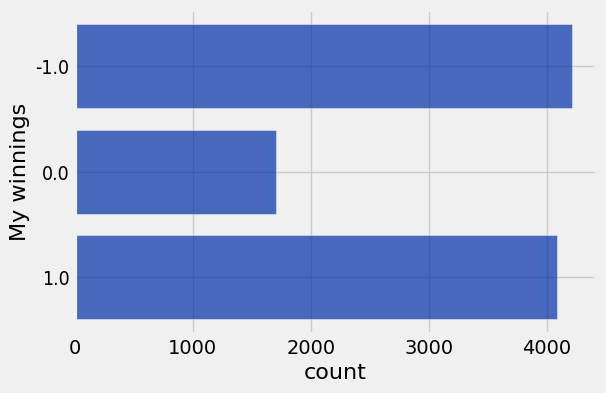

In [193]:
results.group('My winnings').barh('My winnings')

In [ ]:
sum(game_outcomes)

### Another example: simulating heads in 100 coin tosses

In [196]:
coin = make_array('heads', 'tails')

In [197]:
sum(np.random.choice(coin, 100) == 'heads')

51

In [198]:
# Simulate one outcome

def num_heads():
    return sum(np.random.choice(coin, 100) == 'heads')

In [199]:
# Decide how many times you want to repeat the experiment

repetitions = 10000

In [200]:
# Simulate that many outcomes

outcomes = make_array()

for i in np.arange(repetitions):
    outcomes = np.append(outcomes, num_heads())

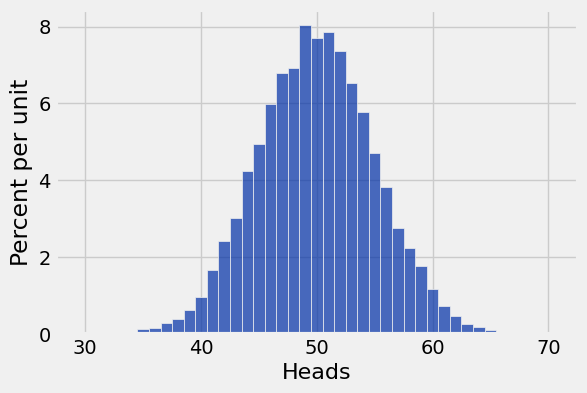

In [201]:
heads = Table().with_column('Heads', outcomes)
heads.hist(bins = np.arange(29.5, 70.6))

## `datascience` library

In [208]:
trip.show(3)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
901821,609,8/24/2015 0:11,Powell at Post (Union Square),71,8/24/2015 0:21,Grant Avenue at Columbus Avenue,73,611,Customer,0
901820,1063,8/23/2015 23:44,Embarcadero at Sansome,60,8/24/2015 0:02,Powell at Post (Union Square),71,383,Customer,0
901713,1550,8/23/2015 17:20,Post at Kearny,47,8/23/2015 17:45,Market at 10th,67,623,Customer,0


In [209]:
trip.where('Duration', are.above(1000))
# .column('Duration')

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
901820,1063,8/23/2015 23:44,Embarcadero at Sansome,60,8/24/2015 0:02,Powell at Post (Union Square),71,383,Customer,0
901713,1550,8/23/2015 17:20,Post at Kearny,47,8/23/2015 17:45,Market at 10th,67,623,Customer,0
878924,11785,8/6/2015 16:02,Civic Center BART (7th at Market),72,8/6/2015 19:18,Embarcadero at Sansome,60,625,Customer,0
878906,12332,8/6/2015 15:52,Civic Center BART (7th at Market),72,8/6/2015 19:18,Embarcadero at Sansome,60,531,Customer,0
871652,8820,8/1/2015 12:03,Commercial at Montgomery,45,8/1/2015 14:30,Harry Bridges Plaza (Ferry Building),50,444,Customer,0
871651,8839,8/1/2015 12:02,Commercial at Montgomery,45,8/1/2015 14:29,Harry Bridges Plaza (Ferry Building),50,390,Customer,0
862514,5698,7/26/2015 16:49,Spear at Folsom,49,7/26/2015 18:24,Spear at Folsom,49,419,Customer,0
854766,6281,7/21/2015 5:13,University and Emerson,35,7/21/2015 6:58,University and Emerson,35,101,Customer,0
852559,4411,7/19/2015 11:17,Civic Center BART (7th at Market),72,7/19/2015 12:31,Market at 4th,76,877,Customer,0
805856,1194,6/13/2015 13:48,Harry Bridges Plaza (Ferry Building),50,6/13/2015 14:08,Embarcadero at Sansome,60,518,Customer,0


In [210]:
big_trip_durations = make_array()

In [211]:
for duration in trip.column('Duration'):
    if duration > 1000:
        big_trip_durations = np.append(big_trip_durations, duration)
np.mean(big_trip_durations)

5259.1915219611847

In [212]:
np.mean(
    trip.where('Duration', are.above(1000)).column('Duration')
)

5259.1915219611847

## Optional: Advanced `where` ##

In [213]:
ages = make_array(16, 22, 18, 15, 19, 15, 16, 21)
age = Table().with_column('Age', ages)

In [214]:
age

Age
16
22
18
15
19
15
16
21


In [215]:
age.where('Age', are.above_or_equal_to(18))

Age
22
18
19
21


In [216]:
voter = ages >= 18

In [217]:
voter

array([False,  True,  True, False,  True, False, False,  True], dtype=bool)

In [218]:
age.where(voter)

Age
22
18
19
21


In [219]:
is_voter = are.above_or_equal_to(18)

In [220]:
type(is_voter)

datascience.predicates._combinable

In [221]:
is_voter(22)

True

In [222]:
is_voter(3)

False

In [223]:
age.apply(is_voter, 'Age')

array([False,  True,  True, False,  True, False, False,  True], dtype=bool)

In [224]:
ages >= 18

array([False,  True,  True, False,  True, False, False,  True], dtype=bool)

In [225]:
voter

array([False,  True,  True, False,  True, False, False,  True], dtype=bool)

In [226]:
def my_voter_function(x):
    return x >= 18

In [227]:
age.where('Age', are.above_or_equal_to(18))

Age
22
18
19
21


In [228]:
age.where(voter)

Age
22
18
19
21
